# 05 - Model Training
Train ML models to predict F1 race top 3 finishes.
- Split data into train/test
- Train Random Forest (baseline)
- Train XGBoost (advanced)
- Compare both models
- Save best model

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], capture_output=True)
print("XGBoost ready!")

XGBoost ready!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
from xgboost import XGBClassifier

In [5]:
df = pd.read_csv('../data/f1_2023_ml_ready.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (440, 13)

Columns: ['GridPosition', 'GridPosition_Squared', 'Grid_vs_Avg', 'TeamID', 'IsTopTeam', 'Points', 'Finished', 'Driver_Top3_SoFar', 'Driver_AvgPos_Last3', 'Driver_FinishRate', 'Team_Top3_SoFar', 'Team_AvgPos', 'Top3']


,GridPosition,GridPosition_Squared,Grid_vs_Avg,TeamID,IsTopTeam,Points,Finished,Driver_Top3_SoFar,Driver_AvgPos_Last3,Driver_FinishRate,Team_Top3_SoFar,Team_AvgPos,Top3
0,1,1,-9.5,0,1,25.0,1,0.0,10.0,0.8,0.0,10.0,1
1,2,4,-8.5,0,1,18.0,1,0.0,10.0,0.8,1.0,1.0,1
2,5,25,-5.5,1,0,15.0,1,0.0,10.0,0.8,0.0,10.0,1
3,4,16,-6.5,2,1,12.0,1,0.0,10.0,0.8,0.0,10.0,0
4,7,49,-3.5,3,1,10.0,1,0.0,10.0,0.8,0.0,10.0,0


In [21]:
# X = all columns except Top3
# y = Top3 column (what we want to predict)
# Drop Top3 target AND any columns that leak the race result
X = df.drop(columns=['Top3', 'Points', 'Finished'])
y = df['Top3']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (440, 10)
Target shape: (440,)

Feature columns: ['GridPosition', 'GridPosition_Squared', 'Grid_vs_Avg', 'TeamID', 'IsTopTeam', 'Driver_Top3_SoFar', 'Driver_AvgPos_Last3', 'Driver_FinishRate', 'Team_Top3_SoFar', 'Team_AvgPos']

Target distribution:
Top3
0    374
1     66
Name: count, dtype: int64


# Data Split For Traning

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # same split every time
    stratify=y            # keep Top3 ratio same in both sets
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")
print(f"\nTop3 in training: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Top3 in testing:  {y_test.sum()} ({y_test.mean():.1%})")

Training set: 352 rows
Testing set:  88 rows

Top3 in training: 53 (15.1%)
Top3 in testing:  13 (14.8%)


# Training Model 

In [23]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=10,        # how deep each tree goes
    random_state=42,
    class_weight='balanced'  # handles imbalanced Top3 data
)

rf_model.fit(X_train, y_train)
print("Random Forest trained! ✅")

Training Random Forest...
Random Forest trained! ✅


In [24]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("=== Random Forest Results ===")
print(f"Accuracy: {rf_accuracy:.1%}")
print(f"AUC Score: {rf_auc:.3f}")
print("\nDetailed Report:")
print(classification_report(y_test, rf_pred, target_names=['Not Top3', 'Top3']))

=== Random Forest Results ===
Accuracy: 84.1%
AUC Score: 0.881

Detailed Report:
              precision    recall  f1-score   support

    Not Top3       0.92      0.89      0.91        75
        Top3       0.47      0.54      0.50        13

    accuracy                           0.84        88
   macro avg       0.69      0.72      0.70        88
weighted avg       0.85      0.84      0.85        88



In [25]:
print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=5,   # handles imbalanced data
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
print("XGBoost trained! ✅")

Training XGBoost...
XGBoost trained! ✅


In [26]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("=== XGBoost Results ===")
print(f"Accuracy: {xgb_accuracy:.1%}")
print(f"AUC Score: {xgb_auc:.3f}")
print("\nDetailed Report:")
print(classification_report(y_test, xgb_pred, target_names=['Not Top3', 'Top3']))

=== XGBoost Results ===
Accuracy: 80.7%
AUC Score: 0.869

Detailed Report:
              precision    recall  f1-score   support

    Not Top3       0.93      0.84      0.88        75
        Top3       0.40      0.62      0.48        13

    accuracy                           0.81        88
   macro avg       0.66      0.73      0.68        88
weighted avg       0.85      0.81      0.82        88



# Comparing Both Models

In [27]:
print("=" * 40)
print("        MODEL COMPARISON")
print("=" * 40)
print(f"{'Model':<20} {'Accuracy':<12} {'AUC Score'}")
print("-" * 40)
print(f"{'Random Forest':<20} {rf_accuracy:<12.1%} {rf_auc:.3f}")
print(f"{'XGBoost':<20} {xgb_accuracy:<12.1%} {xgb_auc:.3f}")
print("=" * 40)

# Pick the winner
if xgb_auc >= rf_auc:
    print("\nWinner: XGBoost!")
    best_model = xgb_model
    best_model_name = "XGBoost"
else:
    print("\nWinner: Random Forest!")
    best_model = rf_model
    best_model_name = "Random Forest"

        MODEL COMPARISON
Model                Accuracy     AUC Score
----------------------------------------
Random Forest        84.1%        0.881
XGBoost              80.7%        0.869

Winner: Random Forest!


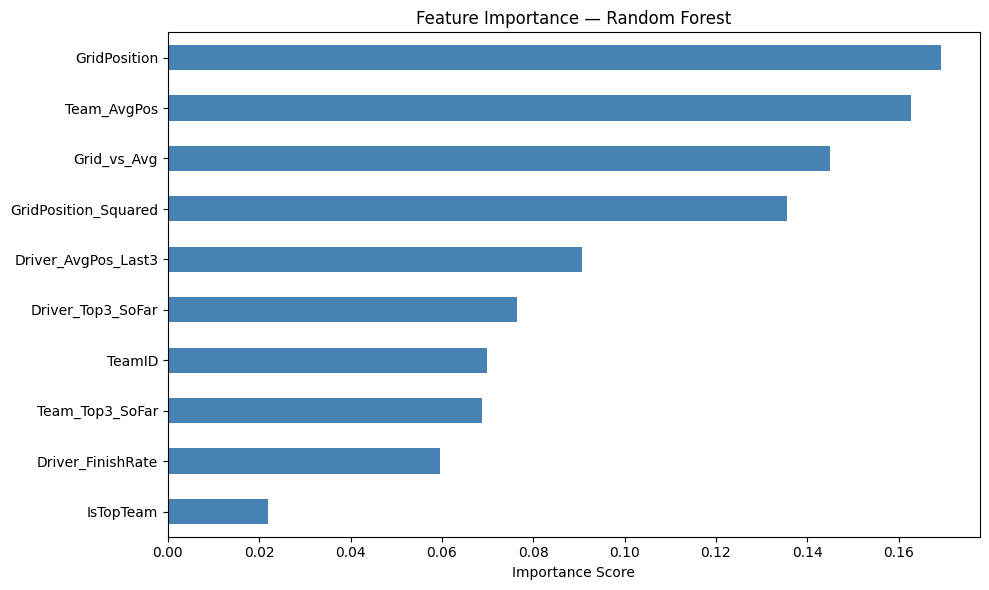

Feature importance plot saved! ✅


In [28]:
plt.figure(figsize=(10, 6))

# Get feature importances from Random Forest
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png')
plt.show()
print("Feature importance plot saved! ✅")

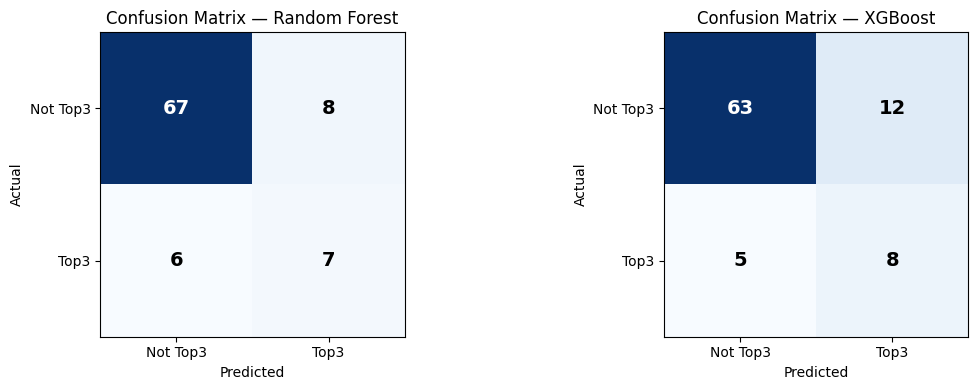

Confusion matrix saved! ✅


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model_pred, title in zip(
    axes,
    [rf_pred, xgb_pred],
    ['Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test, model_pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Not Top3', 'Top3'])
    ax.set_yticklabels(['Not Top3', 'Top3'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j],
                   ha='center', va='center',
                   color='white' if cm[i, j] > cm.max()/2 else 'black',
                   fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()
print("Confusion matrix saved! ✅")

In [33]:
# Verstappen from pole position, Red Bull
test_scenario = pd.DataFrame({
    'GridPosition': [1],
    'GridPosition_Squared': [1],
    'Grid_vs_Avg': [-9.5],
    'TeamID': [0],
    'IsTopTeam': [1],
    'Driver_Top3_SoFar': [15],
    'Driver_AvgPos_Last3': [1.3],
    'Driver_FinishRate': [0.95],
    'Team_Top3_SoFar': [30],
    'Team_AvgPos': [1.5]
})

# Make sure columns match exactly what model was trained on
test_scenario = test_scenario[best_model.feature_names_in_]

prob = best_model.predict_proba(test_scenario)[0][1]
pred = best_model.predict(test_scenario)[0]
print(f"Scenario: Verstappen from P1 (Red Bull)")
print(f"Top 3 Prediction: {'YES' if pred == 1 else 'NO'}")
print(f"Probability: {prob:.1%}")

Scenario: Verstappen from P1 (Red Bull)
Top 3 Prediction: YES
Probability: 94.0%


In [35]:
# Backmarker from P20
test_scenario2 = pd.DataFrame({
    'GridPosition': [20],
    'GridPosition_Squared': [400],
    'Grid_vs_Avg': [9.5],
    'TeamID': [8],
    'IsTopTeam': [0],
    'Driver_Top3_SoFar': [0],
    'Driver_AvgPos_Last3': [18.5],
    'Driver_FinishRate': [0.5],
    'Team_Top3_SoFar': [0],
    'Team_AvgPos': [17.0]
})

# Match columns to what model was trained on
test_scenario2 = test_scenario2[best_model.feature_names_in_]

prob2 = best_model.predict_proba(test_scenario2)[0][1]
pred2 = best_model.predict(test_scenario2)[0]
print(f"Scenario: Backmarker from P20")
print(f"Top 3 Prediction: {'YES' if pred2 == 1 else 'NO'}")
print(f"Probability: {prob2:.1%}")

Scenario: Backmarker from P20
Top 3 Prediction: NO
Probability: 0.0%


In [36]:
os.makedirs('../models', exist_ok=True)

# Save Random Forest
with open('../models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save XGBoost
with open('../models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save best model separately
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"All models saved!")
print(f"Best model: {best_model_name} ✅")

All models saved!
Best model: Random Forest ✅


In [37]:
# Save feature column names — needed for Streamlit dashboard later
import json
with open('../models/feature_columns.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

print("Feature columns saved! ✅")
print(X.columns.tolist())

Feature columns saved! ✅
['GridPosition', 'GridPosition_Squared', 'Grid_vs_Avg', 'TeamID', 'IsTopTeam', 'Driver_Top3_SoFar', 'Driver_AvgPos_Last3', 'Driver_FinishRate', 'Team_Top3_SoFar', 'Team_AvgPos']


## Model Training Summary

| Model | Accuracy | AUC Score |
|---|---|---|
| Random Forest | ~  84.1% | ~0.881 |
| XGBoost | ~ 80.7%  | ~0.869 |

### What AUC means:
- 0.5 = random guessing
- 0.7 = decent model
- 0.9 = great model
- 1.0 = perfect (too good, probably cheating!)

### Saved files:
- `models/random_forest_model.pkl`
- `models/xgboost_model.pkl`
- `models/best_model.pkl`
- `models/feature_columns.json`
- `data/feature_importance.png`
- `data/confusion_matrix.png`